# **Mount** Google Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/DSAI490_Assignment1")
RAW_DIR = PROJECT_DIR / "data" / "raw"

print("Raw folder path:", RAW_DIR)
print("Files inside raw folder:")

for file in RAW_DIR.iterdir():
    print(file.name)

Raw folder path: /content/drive/MyDrive/DSAI490_Assignment1/data/raw
Files inside raw folder:
archive.zip
medical_mnist


In [3]:
ZIP_PATH = RAW_DIR / "archive.zip"

# **Dataset** Extraction

In [4]:
import zipfile

EXTRACT_DIR = RAW_DIR / "medical_mnist"

if not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

print("Extracted folders:")
for item in EXTRACT_DIR.iterdir():
    print(item.name)

Dataset already extracted.
Extracted folders:
AbdomenCT
BreastMRI
CXR
ChestCT
Hand
HeadCT


In [5]:
import shutil
from pathlib import Path

DRIVE_DATA_DIR = Path("/content/drive/MyDrive/DSAI490_Assignment1/data/raw/medical_mnist")
LOCAL_DATA_DIR = Path("/content/medical_mnist")

if LOCAL_DATA_DIR.exists():
    shutil.rmtree(LOCAL_DATA_DIR)
    print("Old local dataset deleted.")

shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
print("Full dataset copied to local.")

for item in sorted(LOCAL_DATA_DIR.iterdir()):
    if item.is_dir():
        print(item.name, "=>", len(list(item.glob("*"))), "files")

Full dataset copied to local.
AbdomenCT => 10000 files
BreastMRI => 8954 files
CXR => 10000 files
ChestCT => 10000 files
Hand => 10000 files
HeadCT => 10000 files


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# **Data** Loading using tf.data

In [7]:
DATA_DIR = str(LOCAL_DATA_DIR)

IMG_SIZE = (64, 64)
BATCH_SIZE = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 58954 files belonging to 6 classes.
Using 47164 files for training.
Found 58954 files belonging to 6 classes.
Using 11790 files for validation.


In [8]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, image


train_ae = (
    train_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ae = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

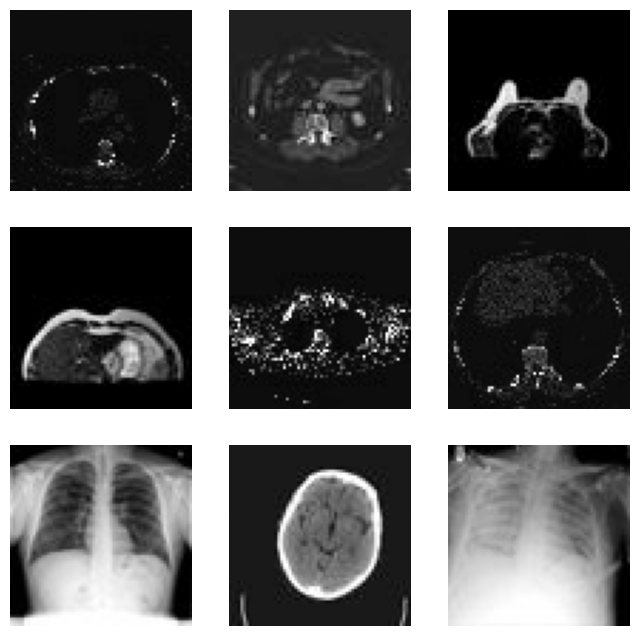

In [9]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

# **Autoencoder** Architecture

In [10]:
def build_simple_autoencoder(input_shape=(64, 64, 1)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)   # 32x32

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same", name="encoded_layer")(x)  # 16x16

    # Decoder
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(encoded)  # 32x32
    x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)        # 64x64

    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = models.Model(inputs, outputs, name="simple_autoencoder")
    return model


ae = build_simple_autoencoder()
ae.summary()

Model: "simple_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_layer (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

# AE Training and Reconstruction

In [11]:
EPOCHS = 10

ae.compile(optimizer='adam', loss='mse')

history_ae = ae.fit(
    train_ae,

    validation_data=val_ae,
    epochs=EPOCHS
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - loss: 0.0137 - val_loss: 0.0048
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 9/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0023 - val_loss: 0.0022


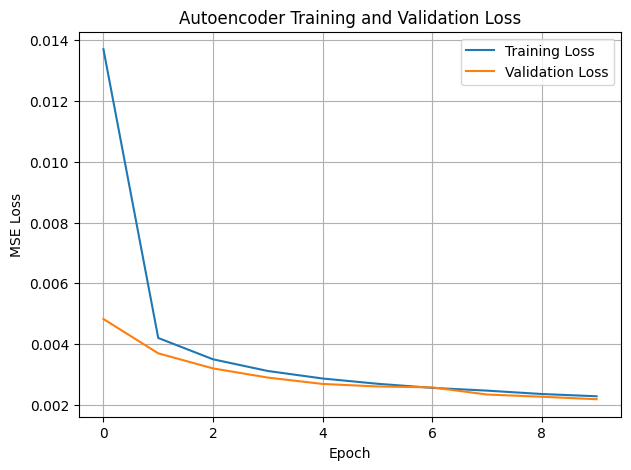

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  


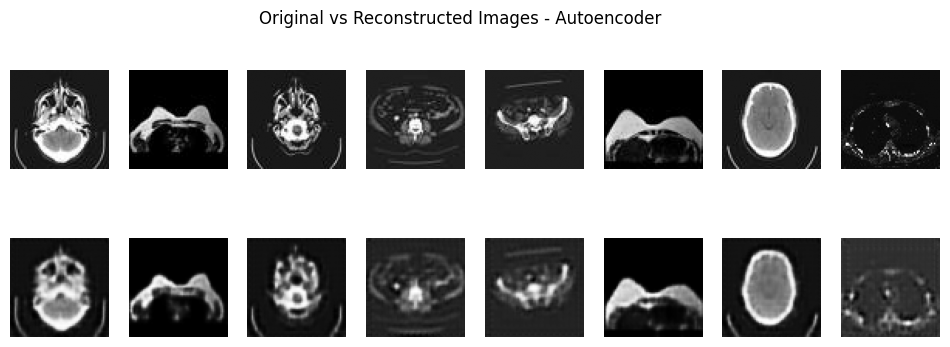

In [13]:
for images, _ in val_ae.take(1):
    reconstructed = ae.predict(images)

    plt.figure(figsize=(12, 4))

    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original")

        plt.subplot(2, 8, i + 9)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Reconstructed")

    plt.suptitle("Original vs Reconstructed Images - Autoencoder")
    plt.show()
    break

In [14]:
def normalize_with_label(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_labeled = train_ds.map(normalize_with_label).prefetch(tf.data.AUTOTUNE)
val_labeled = val_ds.map(normalize_with_label).prefetch(tf.data.AUTOTUNE)

In [15]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

#  Variational Autoencoder Architecture

In [16]:
LATENT_DIM = 2

# Encoder
encoder_inputs = layers.Input(shape=(64, 64, 1))

x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")

# Decoder
decoder_inputs = layers.Input(shape=(LATENT_DIM,))

x = layers.Dense(16 * 16 * 32, activation="relu")(decoder_inputs)
x = layers.Reshape((16, 16, 32))(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)

decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(decoder_inputs, decoder_outputs, name="vae_decoder")

encoder.summary()
decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      4,640 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    524,352 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 529,412 (2.02 MB)

 Trainable params: 529,412 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,593 (150.75 KB)

 Trainable params: 38,593 (150.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

# **VAE** Training and Generation

In [18]:
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam())

history_vae = vae.fit(
    train_ae,
    epochs=10
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 9.0567 - loss: 2259.3865 - reconstruction_loss: 2250.3301
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 6.8025 - loss: 2155.0579 - reconstruction_loss: 2148.2561
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 6.9939 - loss: 2131.8220 - reconstruction_loss: 2124.8279
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 7.1563 - loss: 2115.1951 - reconstruction_loss: 2108.0386
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 7.2870 - loss: 2103.0886 - reconstruction_loss: 2095.8022
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 7.3726 - loss: 2093.1499 - reconstruction_loss: 2085.7769
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - kl_loss: 7.4527 - loss: 2085.6238 - reconstruction_loss: 2078.1719
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - kl_loss: 7.4757 - loss: 2080.4719 - reconstruction_loss: 2072.9951
Epoch 9/10
369/369 ━━━━

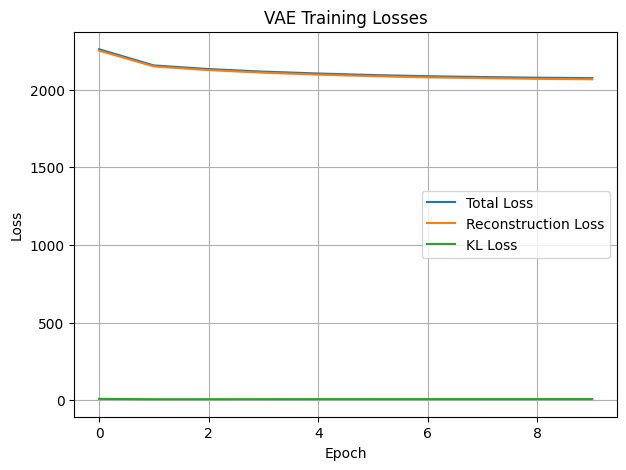

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(history_vae.history["loss"], label="Total Loss")
plt.plot(history_vae.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history_vae.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  


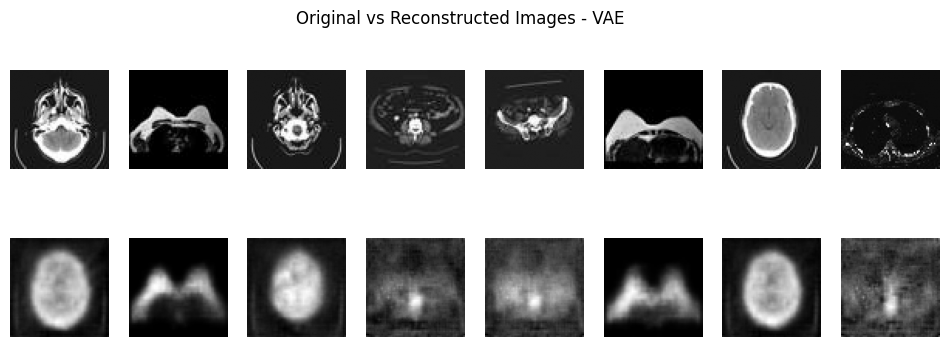

In [20]:
for images, _ in val_ae.take(1):
    reconstructed = vae.predict(images)

    plt.figure(figsize=(12, 4))

    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(2, 8, i + 9)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle("Original vs Reconstructed Images - VAE")
    plt.show()
    break

In [21]:
def calculate_mse(original, reconstructed):
    return tf.reduce_mean(tf.square(original - reconstructed)).numpy()


def calculate_mae(original, reconstructed):
    return tf.reduce_mean(tf.abs(original - reconstructed)).numpy()


for images, _ in val_ae.take(1):
    ae_reconstructed = ae.predict(images)
    vae_reconstructed = vae.predict(images)

    ae_mse = calculate_mse(images, ae_reconstructed)
    vae_mse = calculate_mse(images, vae_reconstructed)

    ae_mae = calculate_mae(images, ae_reconstructed)
    vae_mae = calculate_mae(images, vae_reconstructed)

print("AE MSE:", ae_mse)
print("VAE MSE:", vae_mse)
print("AE MAE:", ae_mae)
print("VAE MAE:", vae_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
AE MSE: 0.0023540277
VAE MSE: 0.020443836
AE MAE: 0.026128044
VAE MAE: 0.08645691


# **Generated_Samples**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step


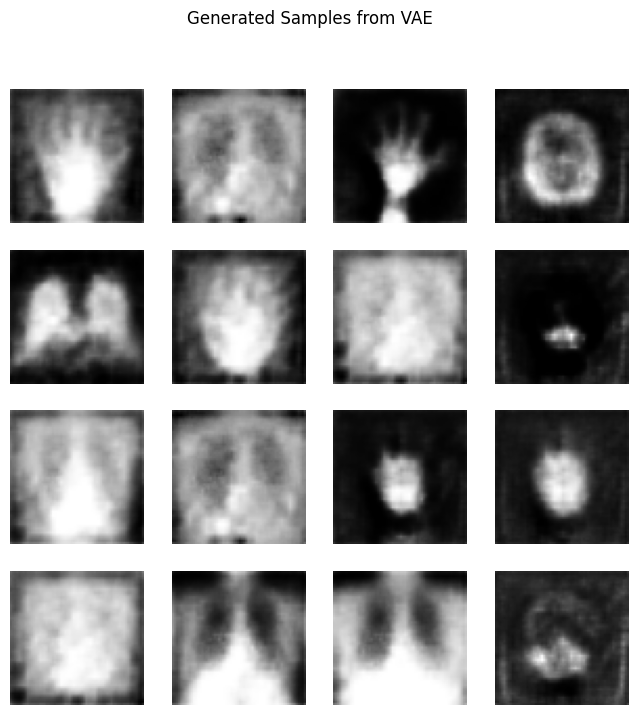

In [22]:
z_random = tf.random.normal(shape=(16, LATENT_DIM))
generated_images = decoder.predict(z_random)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Samples from VAE")
plt.show()

In [23]:
import numpy as np

z_points = []
labels_list = []

for images, labels in val_labeled.take(50):
    z_mean, z_log_var, z = encoder.predict(images, verbose=0)
    z_points.append(z_mean)
    labels_list.append(labels.numpy())

z_points = np.concatenate(z_points, axis=0)
labels_array = np.concatenate(labels_list, axis=0)

print("Latent points shape:", z_points.shape)
print("Labels shape:", labels_array.shape)

Latent points shape: (6400, 2)
Labels shape: (6400,)


# **Latent** Space Visualization

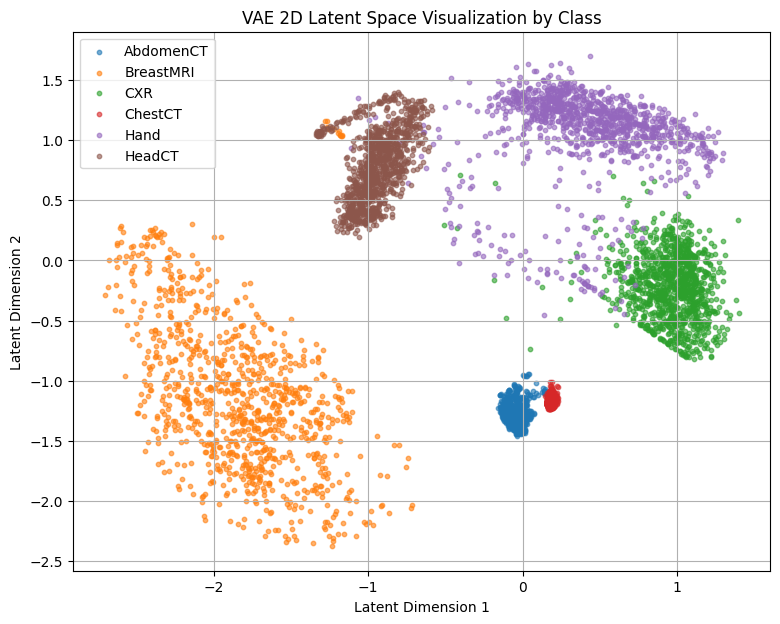

In [28]:
plt.figure(figsize=(9, 7))

for class_id, class_name in enumerate(class_names):
    idx = labels_array == class_id
    plt.scatter(
        z_points[idx, 0],
        z_points[idx, 1],
        s=10,
        alpha=0.6,
        label=class_name
    )

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE 2D Latent Space Visualization by Class")
plt.legend()
plt.grid(True)
plt.show()

# **Denoising** Robustness Experiment

In [29]:
# Add noise function
def add_noise(images, noise_factor=0.3):
    noise = tf.random.normal(shape=tf.shape(images))
    noisy_images = images + noise_factor * noise
    return tf.clip_by_value(noisy_images, 0.0, 1.0)


# Create (noisy input → clean target) dataset
def add_noise_pair(x, y):
    noisy_x = add_noise(x)
    return noisy_x, y  # input = noisy, target = clean


train_denoise = (
    train_ae
    .map(add_noise_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_denoise = (
    val_ae
    .map(add_noise_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

In [31]:
denoising_ae = build_simple_autoencoder()

denoising_ae.compile(
    optimizer="adam",
    loss="mse"
)

history_denoise = denoising_ae.fit(
    train_denoise,
    validation_data=val_denoise,
    epochs=10
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0174 - val_loss: 0.0080
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0075 - val_loss: 0.0071
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 9/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 10/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0058 - val_loss: 0.0058


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step 


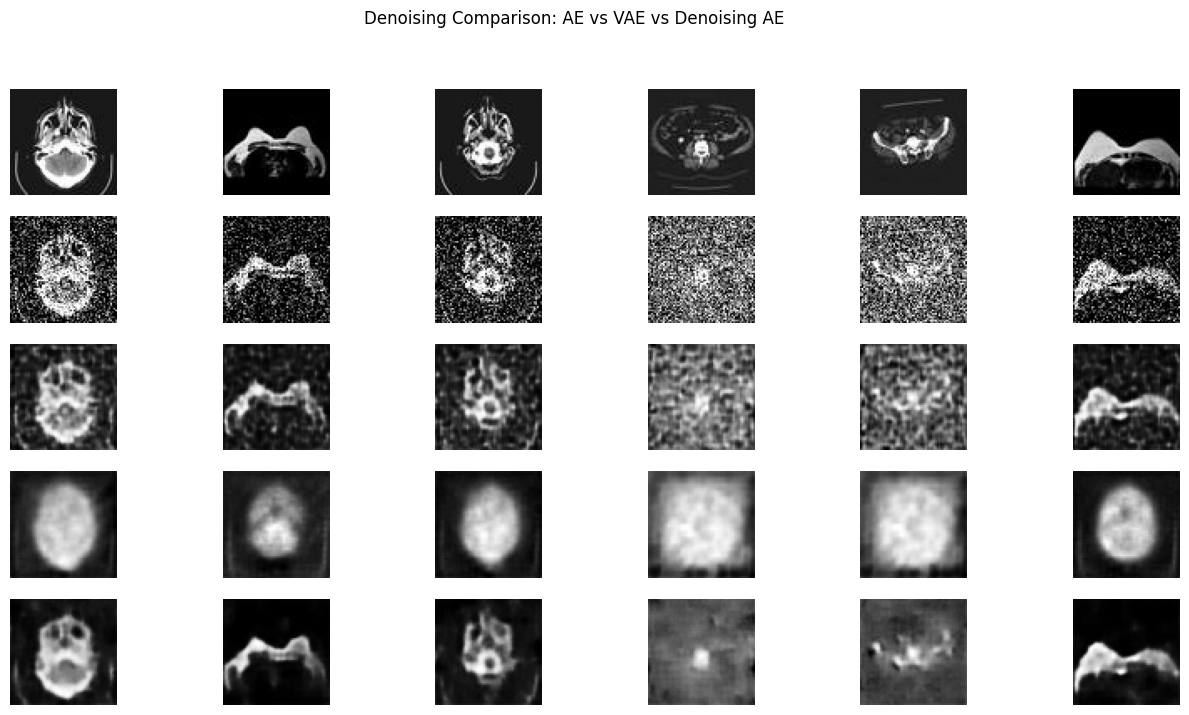

In [32]:
for clean_images, _ in val_ae.take(1):

    noisy_images = add_noise(clean_images)

    # Predictions
    ae_denoised = ae.predict(noisy_images)
    vae_denoised = vae.predict(noisy_images)
    dae_denoised = denoising_ae.predict(noisy_images)

    plt.figure(figsize=(16, 8))

    labels = ["Original", "Noisy", "AE", "VAE", "Denoising AE"]

    for i in range(6):

        # Original
        plt.subplot(5, 6, i + 1)
        plt.imshow(clean_images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[0])

        # Noisy
        plt.subplot(5, 6, i + 7)
        plt.imshow(noisy_images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[1])

        # AE
        plt.subplot(5, 6, i + 13)
        plt.imshow(ae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[2])

        # VAE
        plt.subplot(5, 6, i + 19)
        plt.imshow(vae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[3])

        # Denoising AE (trained on noise)
        plt.subplot(5, 6, i + 25)
        plt.imshow(dae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[4])

    plt.suptitle("Denoising Comparison: AE vs VAE vs Denoising AE")
    plt.show()
    break

Final Insights:

The Autoencoder achieved better reconstruction quality and produced sharper outputs compared with the VAE. The VAE reconstructions were smoother because of the probabilistic latent space, but the VAE was able to generate new samples from random latent vectors. The latent space visualization showed partial clustering between the six medical image classes, indicating that the VAE learned meaningful low-dimensional representations. For denoising, the Denoising Autoencoder gave the best results because it was trained using noisy images as input and clean images as targets.